Loading Qwen2-0.5B...


Loaded pretrained model Qwen/Qwen2-0.5B into HookedTransformer
Model loaded successfully!
Recording clean brain activity...
Swapping brain layers one by one to find the Nutrition Circuit...
Drawing the graph...


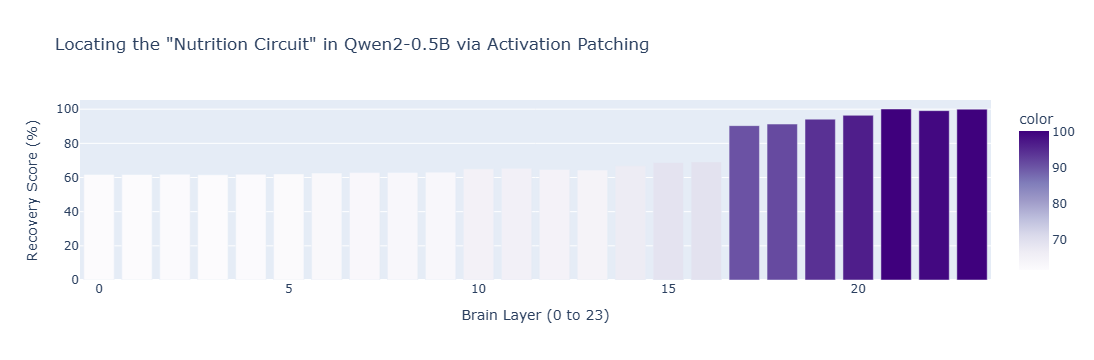

In [5]:
import torch
import plotly.express as px
from transformer_lens import HookedTransformer

#Load the model
print("Loading Qwen2-0.5B...")
model = HookedTransformer.from_pretrained("Qwen/Qwen2-0.5B")
print("Model loaded successfully!")

# Define the Experiment (The "Burger vs. Apple" Test)
# Prompt A (Clean): We want it to predict " apple"
clean_prompt = "For a healthy snack, I eat an"
clean_answer = " apple"

# Prompt B (Corrupted/Lie): We want it to predict " burger"
corrupted_prompt = "For a junk food, I eat a"
corrupted_answer = " burger"

# Get the internal ID numbers for the words " apple" and " burger"
# prepend_bos=False prevents adding an extra "beginning of sentence" token here
clean_token = model.to_tokens(clean_answer, prepend_bos=False)[0, 0].item()
corrupted_token = model.to_tokens(corrupted_answer, prepend_bos=False)[0, 0].item()

# Run the "Clean" prompt and record the perfect brain activity
print("Recording clean brain activity...")
clean_logits, clean_cache = model.run_with_cache(clean_prompt)

# Define our Score: How well is it predicting Apple instead of Burger?
# A positive score means it likes Apple. A negative score means it likes Burger.
def get_score(logits):
    final_word_logits = logits[0, -1, :] # Look at the very last word's predictions
    return final_word_logits[clean_token] - final_word_logits[corrupted_token]

clean_score = get_score(clean_logits)

#Run the "Corrupted" prompt to see its baseline "junk food" response
corrupted_logits = model(corrupted_prompt)
corrupted_score = get_score(corrupted_logits)

#The Brain Swap (Activation Patching)
n_layers = model.cfg.n_layers
recovery_percentages = []

print("Swapping brain layers one by one to find the Nutrition Circuit...")
for layer in range(n_layers):
    
    def patch_hook(corrupted_activation, hook):
        corrupted_activation[:, -1, :] = clean_cache[hook.name][:, -1, :]
        return corrupted_activation

    # We are targeting the main output stream (resid_post) of each layer
    hook_name = f"blocks.{layer}.hook_resid_post"

    # Run the model on the "junk food" prompt, but apply the swap
    patched_logits = model.run_with_hooks(
        corrupted_prompt,
        fwd_hooks=[(hook_name, patch_hook)]
    )

    # Measure how much the model got "fixed" by this specific layer swap
    patched_score = get_score(patched_logits)
    
    # Convert to a percentage (0% = stayed Burger, 100% = swapped perfectly to Apple)
    recovery_pct = (patched_score - corrupted_score) / (clean_score - corrupted_score)
    recovery_percentages.append(recovery_pct.item() * 100)
    
#Draw the Graph
print("Drawing the graph...")
fig = px.bar(
    x=list(range(n_layers)), 
    y=recovery_percentages,
    labels={'x': 'Brain Layer (0 to 23)', 'y': 'Recovery Score (%)'},
    title='Locating the "Nutrition Circuit" in Qwen2-0.5B via Activation Patching',
    color=recovery_percentages,
    color_continuous_scale='Purples'
)
fig.show()